In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import gc

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('float_format', '{:f}'.format)
warnings.filterwarnings('ignore')

In [2]:
import missingno as msno
%matplotlib inline

In [3]:
train = pd.read_csv('../input/tabular-playground-series-nov-2021/train.csv').drop('id', axis=1)
test  = pd.read_csv('../input/tabular-playground-series-nov-2021/test.csv').drop('id', axis=1)
ss    = pd.read_csv('../input/tabular-playground-series-nov-2021/sample_submission.csv')

In [4]:
train.head(10)

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
0,0.106643,3.594370,132.804000,3.184280,0.081971,1.188590,3.732380,2.266270,2.099590,0.012330,1.607190,-0.318058,0.560137,2.806880,1.351140,2.535930,0.197527,0.676494,1.989790,-3.842450,0.037380,0.230322,3.330550,0.009397,0.144738,3.051310,1.303620,0.033225,-0.018284,2.748210,-0.009294,-0.036271,-0.049871,0.019484,3.898460,11.286300,1.138020,3.366880,4.944460,-0.105772,2.113450,3.452230,0.789430,1.113210,1.491570,2.440370,0.041824,3.355370,0.053691,1.701270,0.908831,0.094902,0.030219,0.597024,4.443410,1.586490,-0.068686,-0.108268,0.061044,0.046099,0.017113,-0.027551,0.019483,-0.048826,0.050748,3.729300,5.017440,4.186880,0.063342,0.121043,1.371750,4.017450,0.167613,0.039753,2.042360,-0.016614,0.107679,3.507250,0.013660,-0.097023,5.396070,0.244457,3.491840,0.113090,-0.015472,4.208790,4.106560,0.037227,-0.118814,0.067086,0.010739,1.098620,0.013331,-0.011715,0.052759,0.065400,4.211250,1.978770,0.085974,0.240496,0
1,0.125021,1.673360,76.533600,3.378250,0.099400,5.093660,1.275620,-0.471318,4.545940,0.037706,0.331749,0.325091,0.062040,2.262150,4.339430,-0.224999,0.233586,3.381280,1.902990,0.067874,-0.051268,0.006135,2.604440,0.103441,0.067638,4.753620,1.855520,-0.181834,0.008359,3.166340,0.011850,0.022292,0.069320,0.117109,0.315276,24.480700,1.672270,-0.409067,4.954750,0.092358,2.603180,1.954690,0.005896,3.289340,2.564530,0.817706,0.025997,4.617490,1.575540,0.066105,0.681634,0.025247,0.183500,0.110038,2.746120,0.835586,0.188196,4.960640,0.136087,-0.008493,-0.015264,-0.010841,0.064584,0.102548,0.093611,0.964089,0.630422,4.307340,0.091289,-0.036360,3.617670,3.103240,0.000657,0.051302,1.924620,0.123294,-0.022671,1.548120,-0.010397,0.058330,3.661310,-0.118386,2.357390,-0.009112,0.178701,4.097350,3.532890,0.005244,0.121381,0.109968,0.135838,3.460170,0.017054,0.124863,0.154064,0.606848,-0.267928,2.577860,-0.020877,0.024719,0
2,0.036330,1.497470,233.546000,2.194350,0.026914,3.126940,5.056870,3.849460,1.801870,0.056995,0.328684,2.968810,0.105244,2.069490,5.309860,1.354790,-0.262018,1.379080,1.480910,0.020542,-0.008806,0.109348,1.683650,0.038180,0.123716,1.112480,3.571660,0.120601,0.082069,2.233520,0.002270,0.045182,0.014405,0.011599,-0.502849,33.738200,1.417500,1.071350,3.222960,2.122030,3.082160,0.637555,-0.006822,-0.390943,17.345700,3.700430,-0.033600,1.578240,0.051978,-0.002004,2.690960,0.018367,-0.030468,0.111409,2.187470,-0.325000,-0.019944,3.455030,0.068105,-0.009812,-0.010627,0.027571,-0.007121,-0.048914,-0.002574,1.865090,2.404170,0.411741,0.057749,0.525174,2.168790,0.828297,0.089848,0.093744,4.949010,-0.010978,0.076671,0.266784,0.038691,0.382731,3.847600,-0.121482,3.740840,0.147098,-0.016566,0.614651,2.125840,0.078828,0.979808,0.026758,0.117310,4.883000,0.085222,0.032396,0.116092,-0.001688,-0.520069,2.141120,0.124464,0.148209,0
3,-0.014077,0.246000,779.967000,1.890640,0.006948,1.531120,2.698000,4.517330,4.503320,0.123494,1.002680,4.869600,0.058411,2.497850,1.238430,2.348360,0.175475,1.608890,2.028810,0.042086,0.005141,0.076506,1.651220,0.111813,0.121641,0.589120,4.236920,-0.032843,0.058168,0.712927,0.097465,0.072744,0.000324,0.063362,4.063820,25.382400,0.576572,2.026210,2.968430,1.085670,1.710880,1.371820,0.034631,0.722607,71.448500,3.034580,0.092245,3.453100,0.044829,0.027195,4.082850,0.046955,0.063695,0.029225,0.672022,0.185311,0.164284,3.804560,0.062306,-0.021406,0.009471,0.110884,0.026837,2.931160,0.068112,-0.495192,1.345280,2.242750,0.035611,-0.139274,4.742430,3.292740,0.117877,0.065605,0.556711,-0.058029,0.070501,1.101250,0.068559,0.162928,4.070180,-0.008835,3.896780,0.913739,-0.163204,3.074850,4.356780,-0.048894,4.917990,0.069930,-0.01

In [5]:
train.shape, test.shape

((600000, 101), (540000, 100))

Lets check if there is any missing values or not.

<AxesSubplot:>

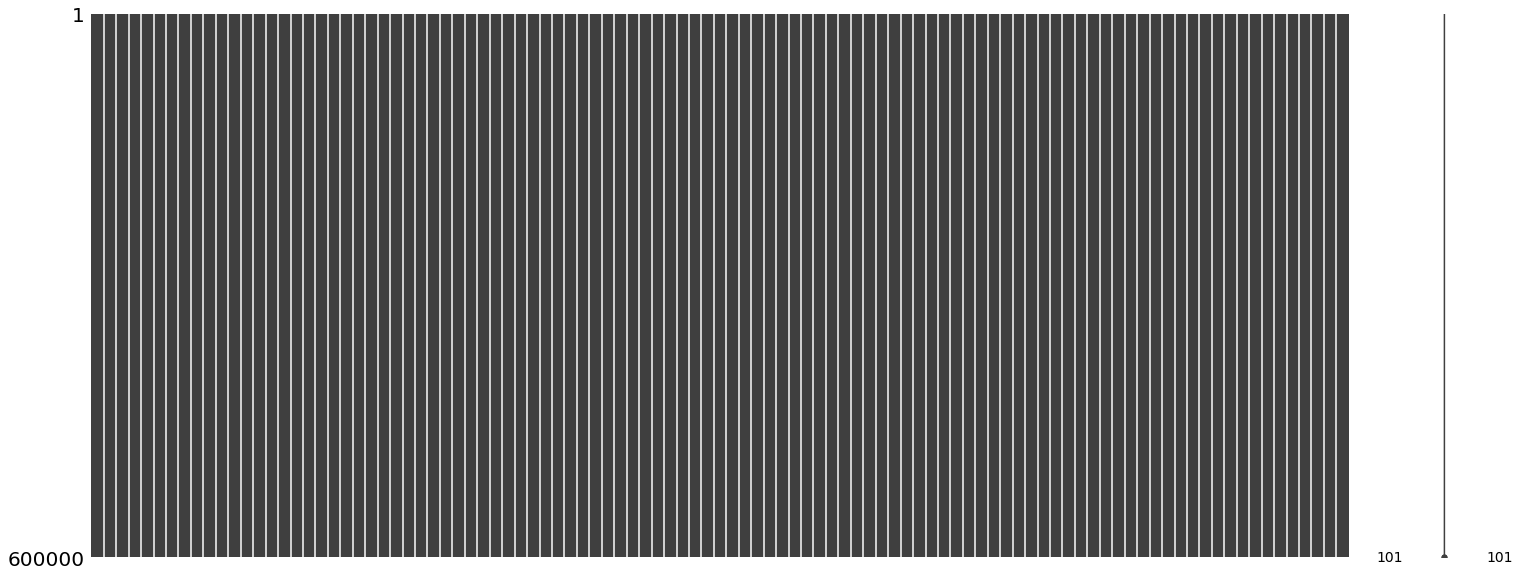

In [6]:
msno.matrix(train)

* We can clearly see that there is no missing values in the dataset.

In [7]:
train.loc[:, 'f0':'f99'].describe().T.style.bar(subset=['mean'], color='#206ff2')\
                            .background_gradient(subset=['std'], cmap='Reds')\
                            .background_gradient(subset=['50%'], cmap='coolwarm')


,count,mean,std,min,25%,50%,75%,max
f0,600000.000000,0.306508,0.522450,-3.797450,0.026222,0.097788,0.397184,8.781500
f1,600000.000000,2.497590,1.554018,-1.223960,1.186238,2.516500,3.787630,6.226720
f2,600000.000000,306.644536,551.743893,-1842.530000,43.573400,133.626000,302.262250,6119.280000
f3,600000.000000,2.647901,1.544529,-1.368560,1.442028,2.634130,3.907640,6.521150
f4,600000.000000,0.177850,0.417488,-3.206210,0.019709,0.061586,0.112712,8.265470
f5,600000.000000,2.556832,1.562527,-1.169770,1.261038,2.590425,3.813662,6.515070
f6,600000.000000,2.699650,1.564000,-1.059310,1.385820,2.801255,3.996913,6.586780
f7,600000.000000,2.571593,1.549361,-1.281970,1.333848,2.557985,3.823450,6.258770
f8,600000.000000,2.538273,1.532988,-1.242020,1.292163,2.475880,3.804360,6.389670
f9,600000.000000,0.134370,0.421892,-2.577840,0.019563,0.058752,0.101046,7.078460


Let's check the distribution of **target** in training dataset.

<AxesSubplot:xlabel='target', ylabel='count'>

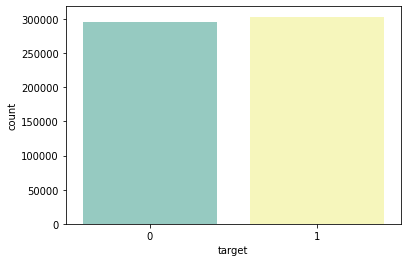

In [8]:
sns.countplot(train['target'], palette='Set3')

This plot shows that there is almost equal distribution of **Target** variable.

# Density plots of features

Here we represent distribution of **train** and **test** in different color.

<Figure size 432x288 with 0 Axes>

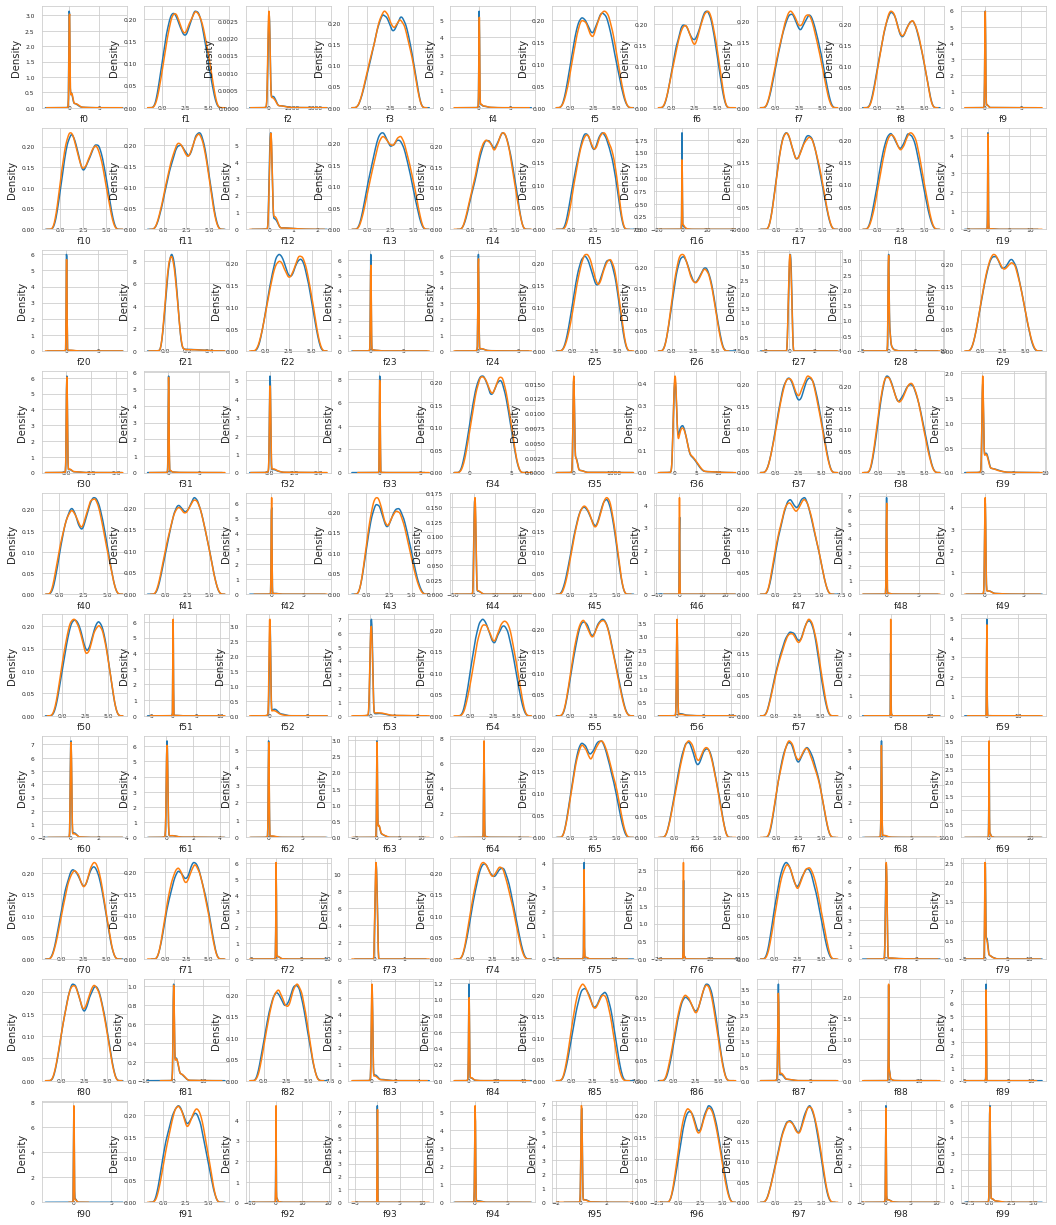

In [9]:
features = train.columns.values[0:100]
i = 0
sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(10,10,figsize=(18,22))

for feature in features:
    i += 1
    plt.subplot(10,10,i)
    sns.distplot(train[feature], hist=False,label='train')
    sns.distplot(test[feature], hist=False,label='test')
    plt.xlabel(feature, fontsize=9)
    locs, labels = plt.xticks()
    plt.tick_params(axis='x', which='major', labelsize=6, pad=-6)
    plt.tick_params(axis='y', which='major', labelsize=6)
plt.show();

Train and test seems to have almost same distribution.

# Distribution of mean and std

Let's check the distribution of the mean values per row in the train and test set.

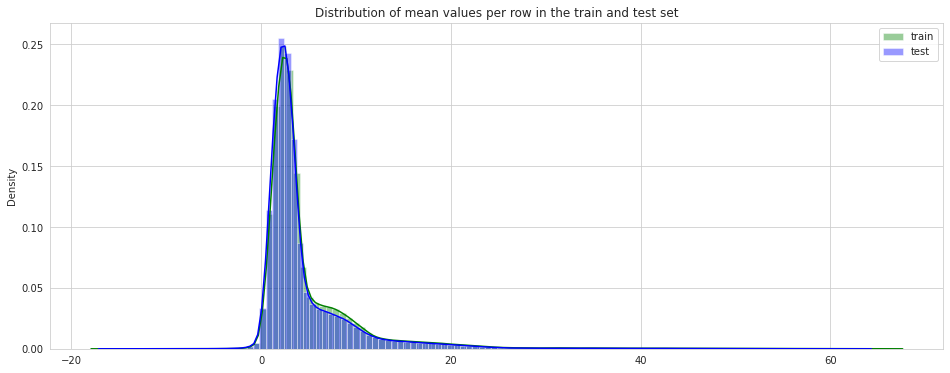

In [10]:
plt.figure(figsize=(16,6))
features = train.columns.values[0:100]
plt.title("Distribution of mean values per row in the train and test set")
sns.distplot(train[features].mean(axis=1),color="green", kde=True,bins=120, label='train')
sns.distplot(test[features].mean(axis=1),color="blue", kde=True,bins=120, label='test')
plt.legend()
plt.show()

Distribution of the **mean** values per **columns** in the train and test set.

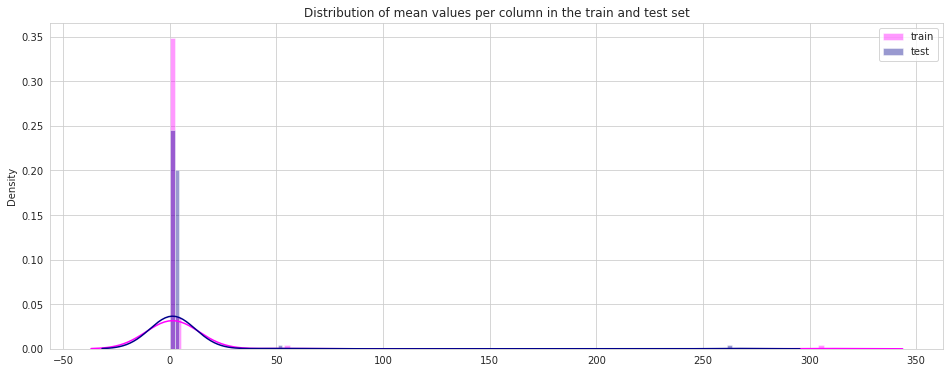

In [11]:
plt.figure(figsize=(16,6))
plt.title("Distribution of mean values per column in the train and test set")
sns.distplot(train[features].mean(axis=0),color="magenta",kde=True,bins=120, label='train')
sns.distplot(test[features].mean(axis=0),color="darkblue", kde=True,bins=120, label='test')
plt.legend()
plt.show()

Distribution of **standard deviation** of values per **row** for train and test datasets.

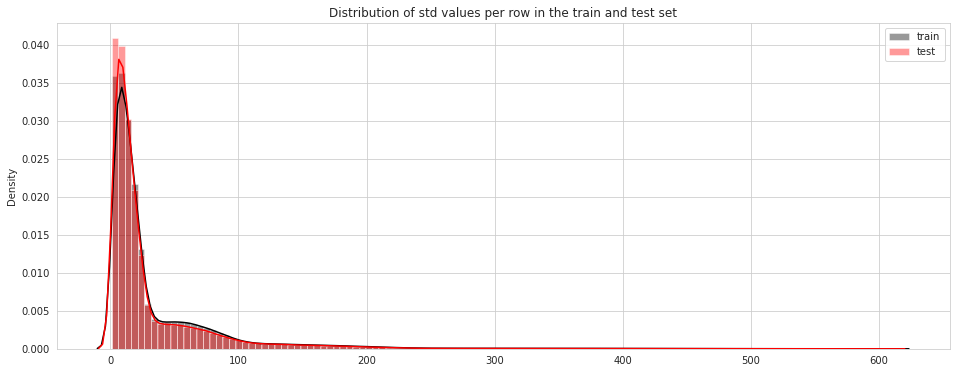

In [12]:
plt.figure(figsize=(16,6))
plt.title("Distribution of std values per row in the train and test set")
sns.distplot(train[features].std(axis=1),color="black", kde=True,bins=120, label='train')
sns.distplot(test[features].std(axis=1),color="red", kde=True,bins=120, label='test')
plt.legend();plt.show()

Distribution of the **standard deviation** of values per **columns** in the train and test datasets.

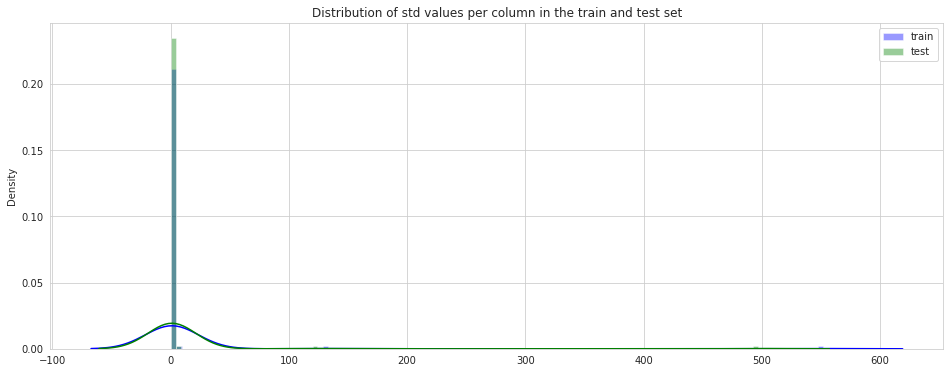

In [13]:
plt.figure(figsize=(16,6))
plt.title("Distribution of std values per column in the train and test set")
sns.distplot(train[features].std(axis=0),color="blue",kde=True,bins=120, label='train')
sns.distplot(test[features].std(axis=0),color="green", kde=True,bins=120, label='test')
plt.legend(); plt.show()

Distribution of the **mean** value per **row** in the train dataset, grouped by value of **target**.

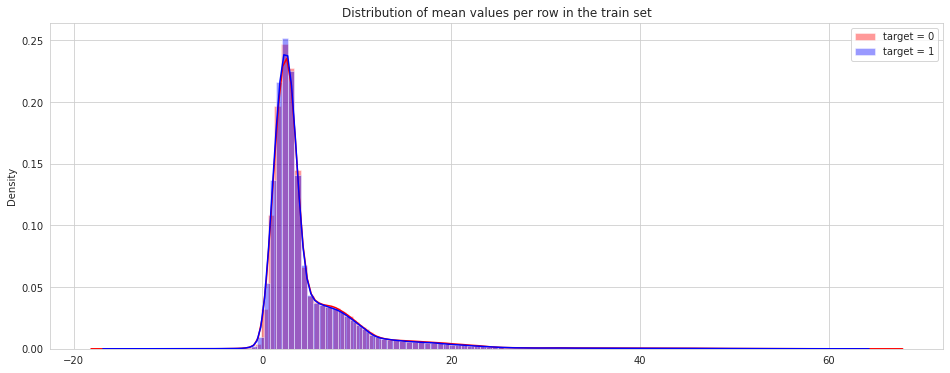

In [14]:
t0 = train.loc[train['target'] == 0]
t1 = train.loc[train['target'] == 1]
plt.figure(figsize=(16,6))
plt.title("Distribution of mean values per row in the train set")
sns.distplot(t0[features].mean(axis=1),color="red", kde=True,bins=120, label='target = 0')
sns.distplot(t1[features].mean(axis=1),color="blue", kde=True,bins=120, label='target = 1')
plt.legend(); plt.show()

Distribution of the **mean** value per **column** in the train dataset, grouped by value of **target**.

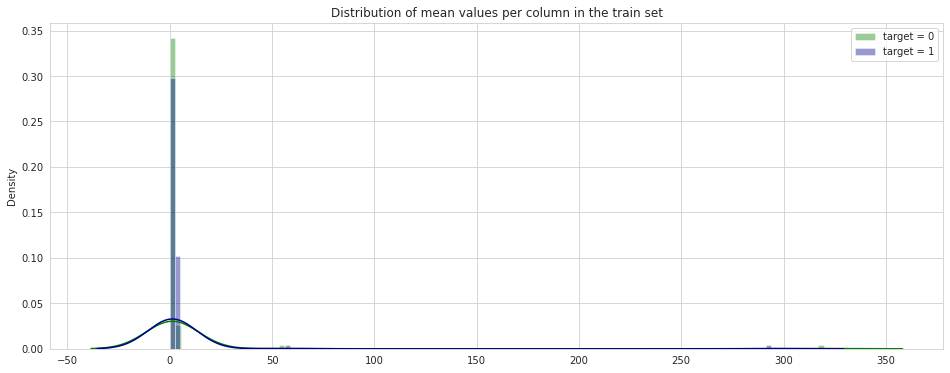

In [15]:
plt.figure(figsize=(16,6))
plt.title("Distribution of mean values per column in the train set")
sns.distplot(t0[features].mean(axis=0),color="green", kde=True,bins=120, label='target = 0')
sns.distplot(t1[features].mean(axis=0),color="darkblue", kde=True,bins=120, label='target = 1')
plt.legend(); plt.show()

# Distribution of min and max

Let's check the distribution of min per row in the train and test set.

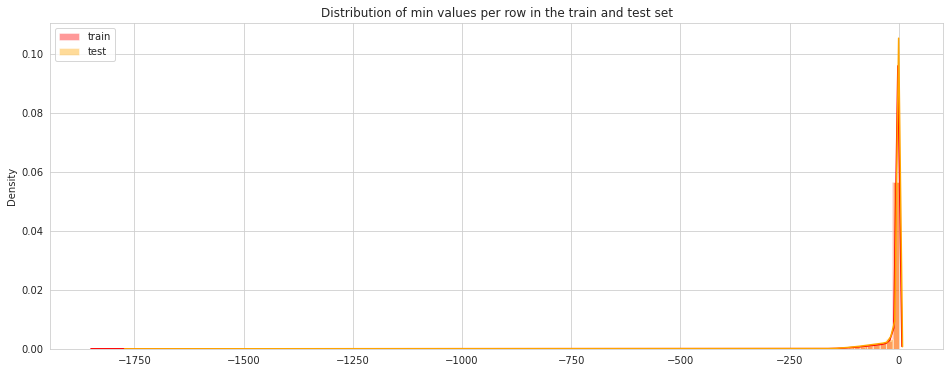

In [16]:
plt.figure(figsize=(16,6))
features = train.columns.values[0:100]
plt.title("Distribution of min values per row in the train and test set")
sns.distplot(train[features].min(axis=1),color="red", kde=True,bins=120, label='train')
sns.distplot(test[features].min(axis=1),color="orange", kde=True,bins=120, label='test')
plt.legend()
plt.show()

Distribution of **min** per **column** in the train and test set.

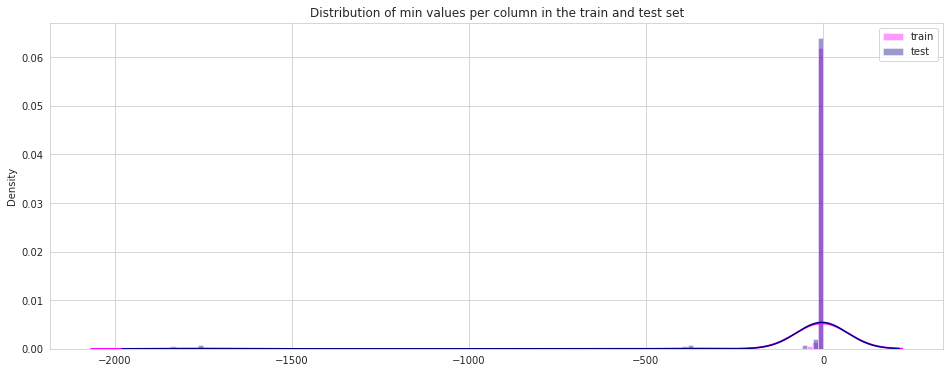

In [17]:
plt.figure(figsize=(16,6))
features = train.columns.values[0:100]
plt.title("Distribution of min values per column in the train and test set")
sns.distplot(train[features].min(axis=0),color="magenta", kde=True,bins=120, label='train')
sns.distplot(test[features].min(axis=0),color="darkblue", kde=True,bins=120, label='test')
plt.legend()
plt.show()

Distribution of **max** values per **rows** for train and test set.

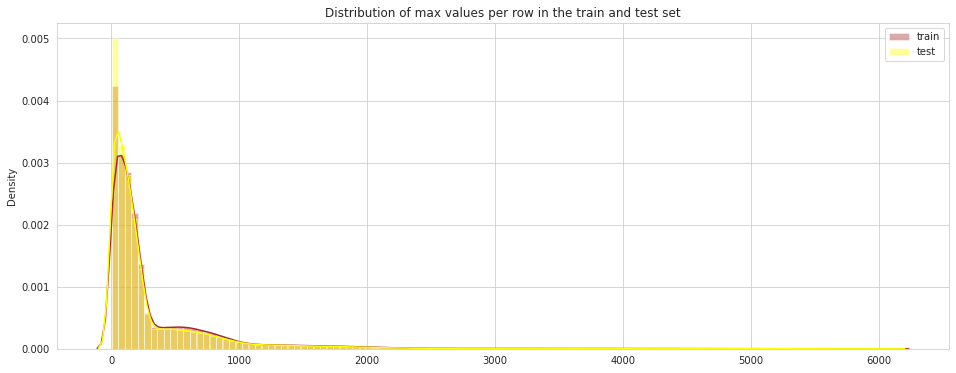

In [18]:
plt.figure(figsize=(16,6))
features = train.columns.values[0:100]
plt.title("Distribution of max values per row in the train and test set")
sns.distplot(train[features].max(axis=1),color="brown", kde=True,bins=120, label='train')
sns.distplot(test[features].max(axis=1),color="yellow", kde=True,bins=120, label='test')
plt.legend()
plt.show()

Now showing the max distribution on columns for train and test set.

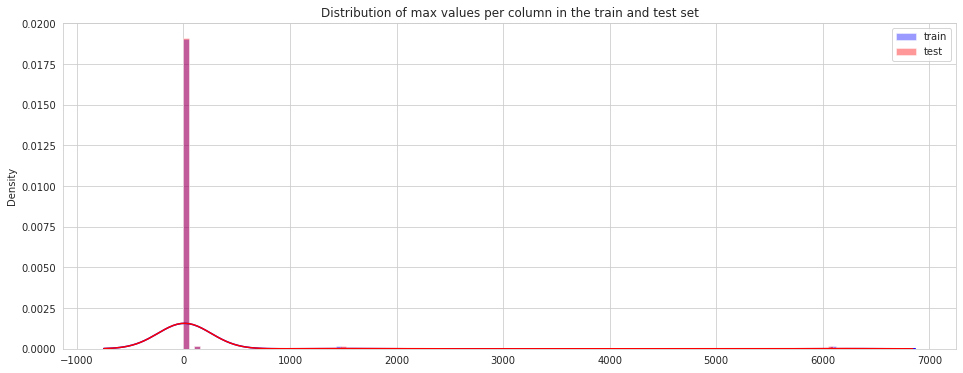

In [19]:
plt.figure(figsize=(16,6))
features = train.columns.values[0:100]
plt.title("Distribution of max values per column in the train and test set")
sns.distplot(train[features].max(axis=0),color="blue", kde=True,bins=120, label='train')
sns.distplot(test[features].max(axis=0),color="red", kde=True,bins=120, label='test')
plt.legend()
plt.show()

Distributions of **min** values per **row** in train set, grouped by value of **target**.

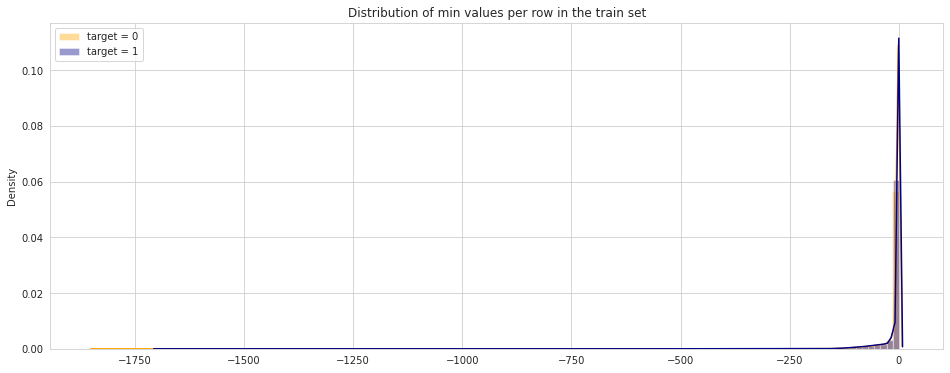

In [20]:
t0 = train.loc[train['target'] == 0]
t1 = train.loc[train['target'] == 1]
plt.figure(figsize=(16,6))
plt.title("Distribution of min values per row in the train set")
sns.distplot(t0[features].min(axis=1),color="orange", kde=True,bins=120, label='target = 0')
sns.distplot(t1[features].min(axis=1),color="darkblue", kde=True,bins=120, label='target = 1')
plt.legend(); plt.show()

Distribution of **min** values per **columns** in train set, grouped by **target**.

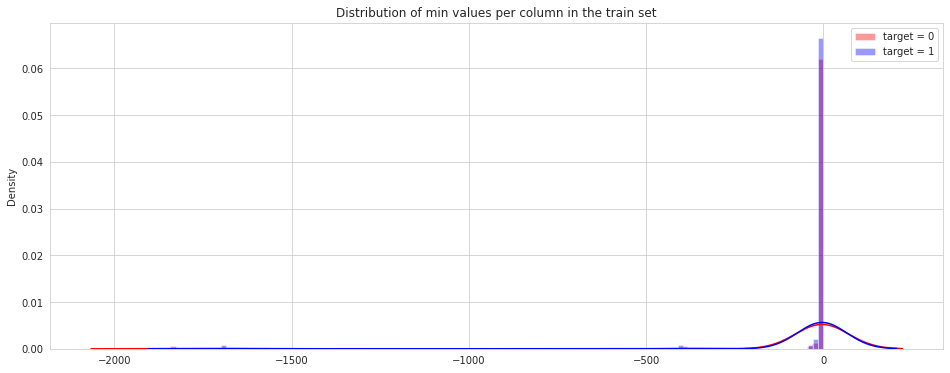

In [21]:
plt.figure(figsize=(16,6))
plt.title("Distribution of min values per column in the train set")
sns.distplot(t0[features].min(axis=0),color="red", kde=True,bins=120, label='target = 0')
sns.distplot(t1[features].min(axis=0),color="blue", kde=True,bins=120, label='target = 1')
plt.legend(); plt.show()

Distribution of **max** values per **row** in the train set, grouped by **target**.

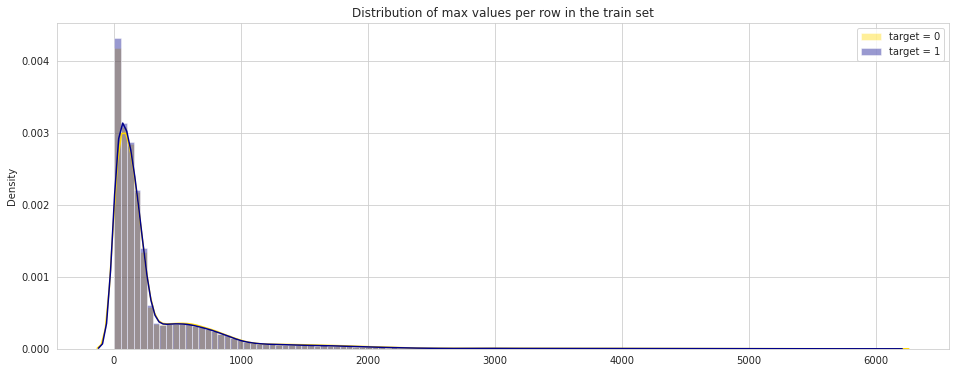

In [22]:
plt.figure(figsize=(16,6))
plt.title("Distribution of max values per row in the train set")
sns.distplot(t0[features].max(axis=1),color="gold", kde=True,bins=120, label='target = 0')
sns.distplot(t1[features].max(axis=1),color="darkblue", kde=True,bins=120, label='target = 1')
plt.legend(); plt.show()

Distribution of **max** values per **columns** in the train set, grouped by **target**.

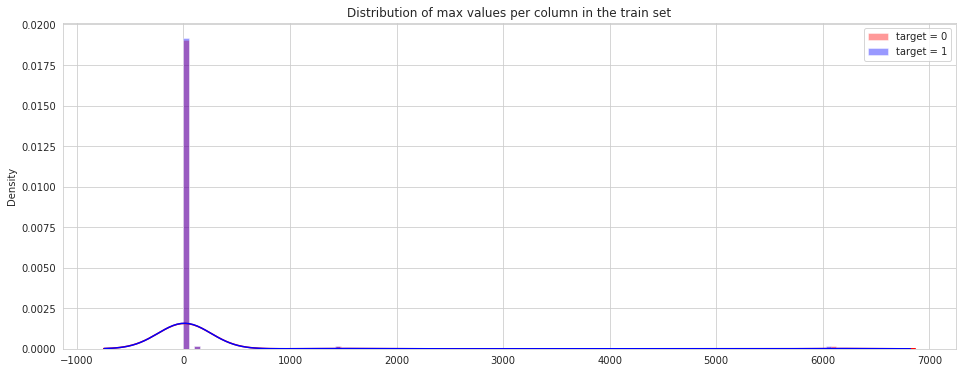

In [23]:
plt.figure(figsize=(16,6))
plt.title("Distribution of max values per column in the train set")
sns.distplot(t0[features].max(axis=0),color="red", kde=True,bins=120, label='target = 0')
sns.distplot(t1[features].max(axis=0),color="blue", kde=True,bins=120, label='target = 1')
plt.legend(); plt.show()

# Distribution of skew and kurtosis

Distribution of **skewness** calculated per **rows** in train and test sets.

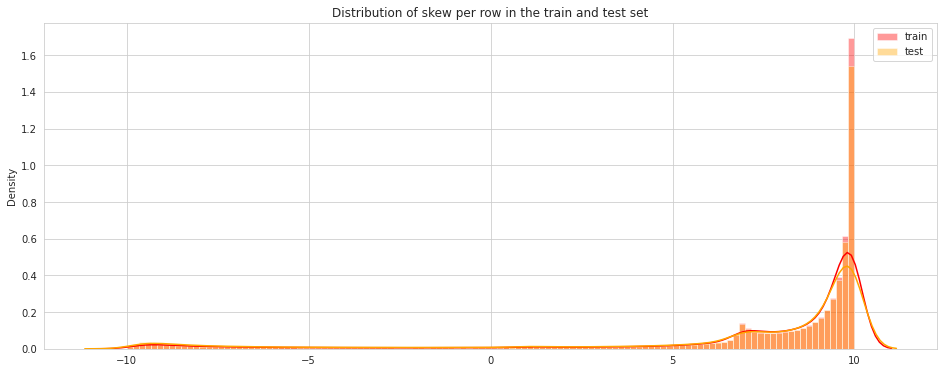

In [24]:
plt.figure(figsize=(16,6))
plt.title("Distribution of skew per row in the train and test set")
sns.distplot(train[features].skew(axis=1),color="red", kde=True,bins=120, label='train')
sns.distplot(test[features].skew(axis=1),color="orange", kde=True,bins=120, label='test')
plt.legend()
plt.show()

Distribution of **skewness** calculated per **columns** in train and test sets.

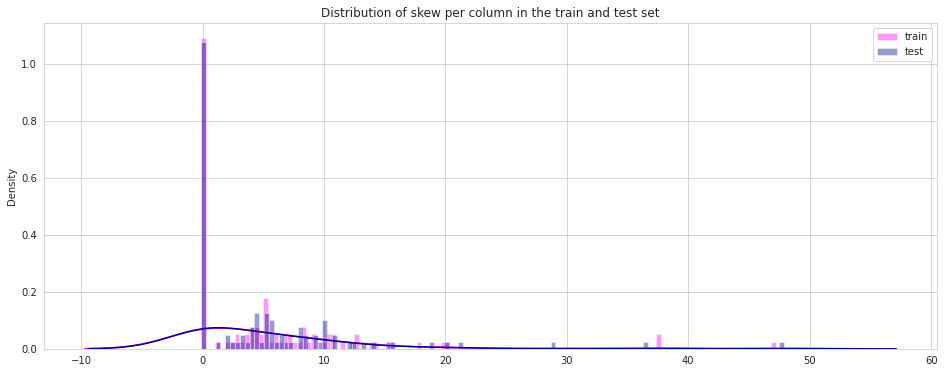

In [25]:
plt.figure(figsize=(16,6))
plt.title("Distribution of skew per column in the train and test set")
sns.distplot(train[features].skew(axis=0),color="magenta", kde=True,bins=120, label='train')
sns.distplot(test[features].skew(axis=0),color="darkblue", kde=True,bins=120, label='test')
plt.legend()
plt.show()

Distribution of **kurtosis** calculated per **rows** in train and test sets.

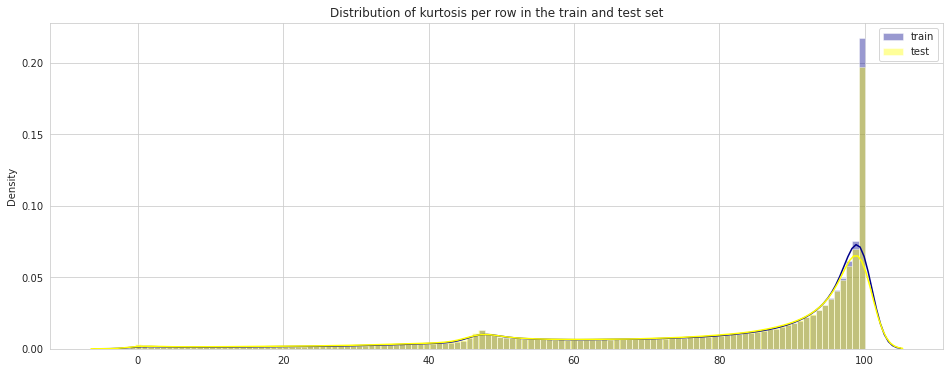

In [26]:
plt.figure(figsize=(16,6))
plt.title("Distribution of kurtosis per row in the train and test set")
sns.distplot(train[features].kurtosis(axis=1),color="darkblue", kde=True,bins=120, label='train')
sns.distplot(test[features].kurtosis(axis=1),color="yellow", kde=True,bins=120, label='test')
plt.legend()
plt.show()

Distribution of **kurtosis** calculated per **columns** in train and test sets.

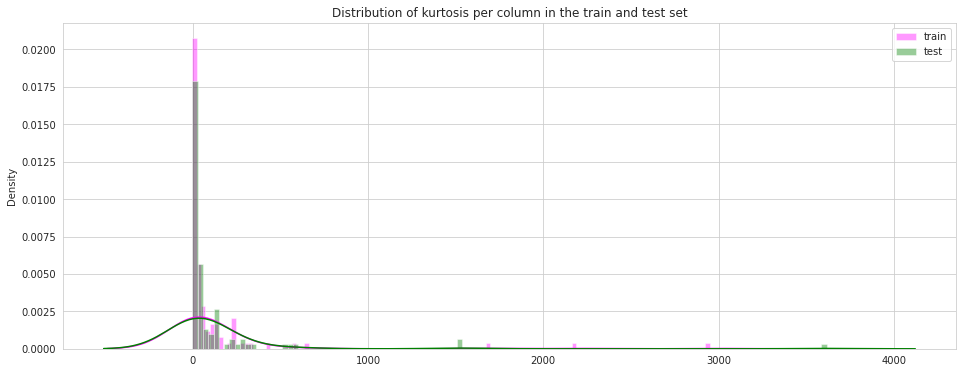

In [27]:
plt.figure(figsize=(16,6))
plt.title("Distribution of kurtosis per column in the train and test set")
sns.distplot(train[features].kurtosis(axis=0),color="magenta", kde=True,bins=120, label='train')
sns.distplot(test[features].kurtosis(axis=0),color="green", kde=True,bins=120, label='test')
plt.legend()
plt.show()

Distribution of **skewness** values per **row** in the train set, grouped by **target**.

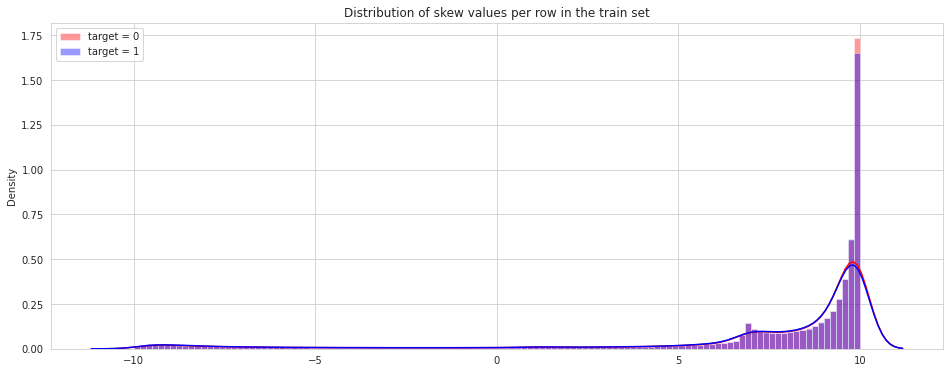

In [28]:
t0 = train.loc[train['target'] == 0]
t1 = train.loc[train['target'] == 1]
plt.figure(figsize=(16,6))
plt.title("Distribution of skew values per row in the train set")
sns.distplot(t0[features].skew(axis=1),color="red", kde=True,bins=120, label='target = 0')
sns.distplot(t1[features].skew(axis=1),color="blue", kde=True,bins=120, label='target = 1')
plt.legend(); plt.show()

Distribution of **skewness** values per **column** in the train set, grouped by **target**.

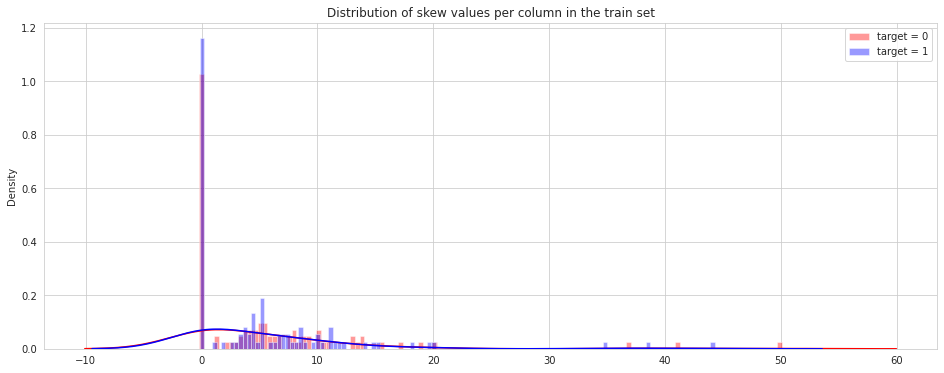

In [29]:
t0 = train.loc[train['target'] == 0]
t1 = train.loc[train['target'] == 1]
plt.figure(figsize=(16,6))
plt.title("Distribution of skew values per column in the train set")
sns.distplot(t0[features].skew(axis=0),color="red", kde=True,bins=120, label='target = 0')
sns.distplot(t1[features].skew(axis=0),color="blue", kde=True,bins=120, label='target = 1')
plt.legend(); plt.show()

Distribution of **kurtosis** values per **row** in the train set, grouped by **target**.

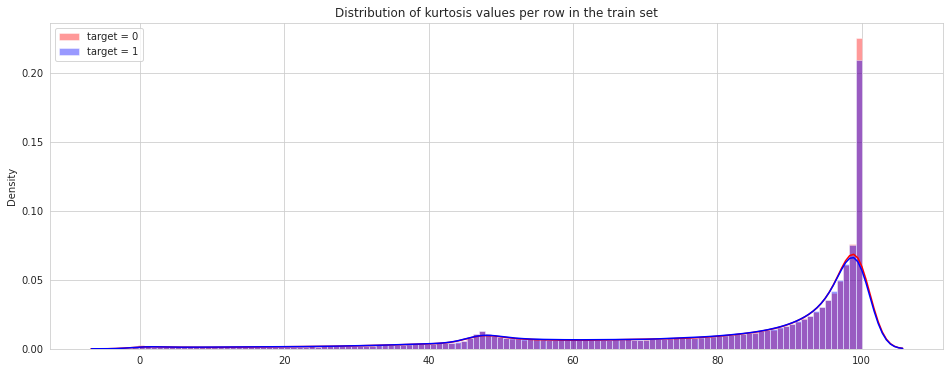

In [30]:
t0 = train.loc[train['target'] == 0]
t1 = train.loc[train['target'] == 1]
plt.figure(figsize=(16,6))
plt.title("Distribution of kurtosis values per row in the train set")
sns.distplot(t0[features].kurtosis(axis=1),color="red", kde=True,bins=120, label='target = 0')
sns.distplot(t1[features].kurtosis(axis=1),color="blue", kde=True,bins=120, label='target = 1')
plt.legend(); plt.show()

Distribution of **kurtosis** values per **column** in the train set, grouped by **target**.

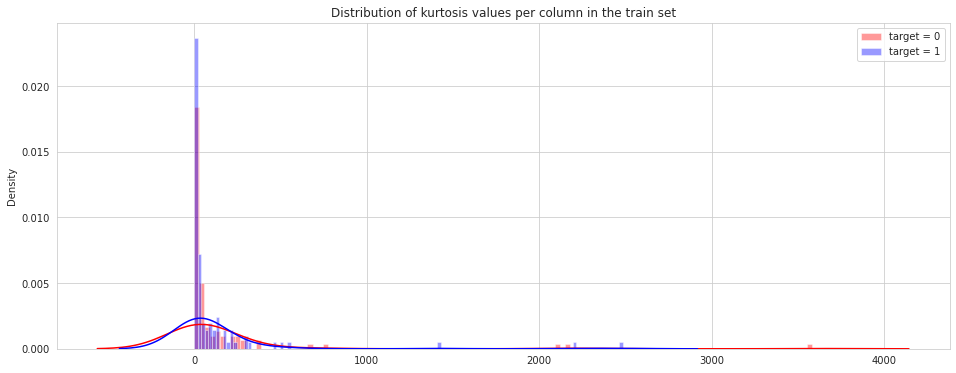

In [31]:
t0 = train.loc[train['target'] == 0]
t1 = train.loc[train['target'] == 1]
plt.figure(figsize=(16,6))
plt.title("Distribution of kurtosis values per column in the train set")
sns.distplot(t0[features].kurtosis(axis=0),color="red", kde=True,bins=120, label='target = 0')
sns.distplot(t1[features].kurtosis(axis=0),color="blue", kde=True,bins=120, label='target = 1')
plt.legend(); plt.show()

# Correlation

Below is a heatmap plot of first 25 features(f0-f24) and target variable.

<AxesSubplot:>

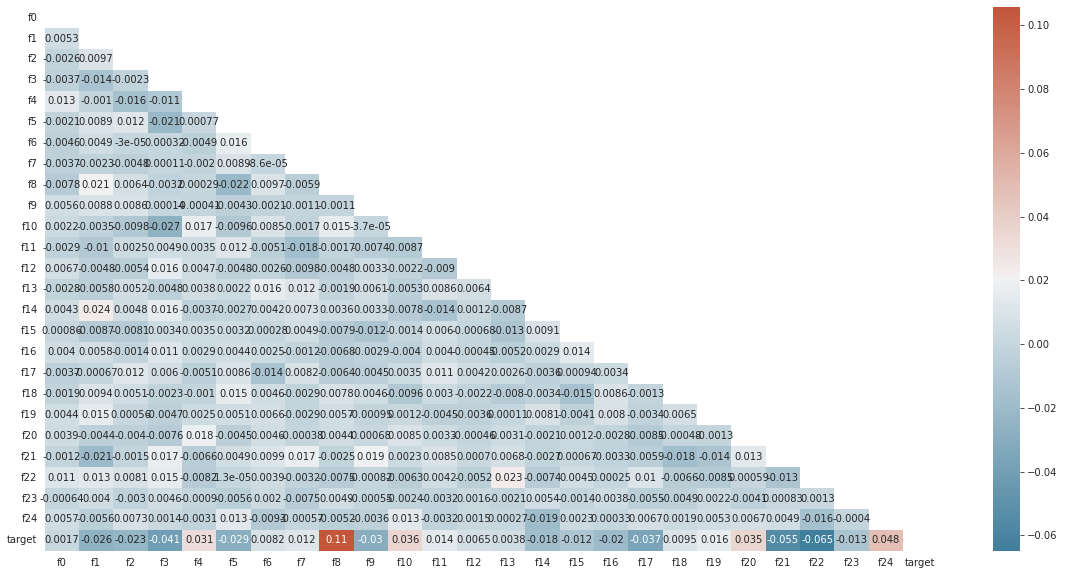

In [32]:
columns = train.columns[0:25].to_list()
columns.append('target')

corr = train[columns].corr()
f, ax = plt.subplots(figsize=(20,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, mask = mask, cmap=cmap)

**f25-f49** and **target** variable.

<AxesSubplot:>

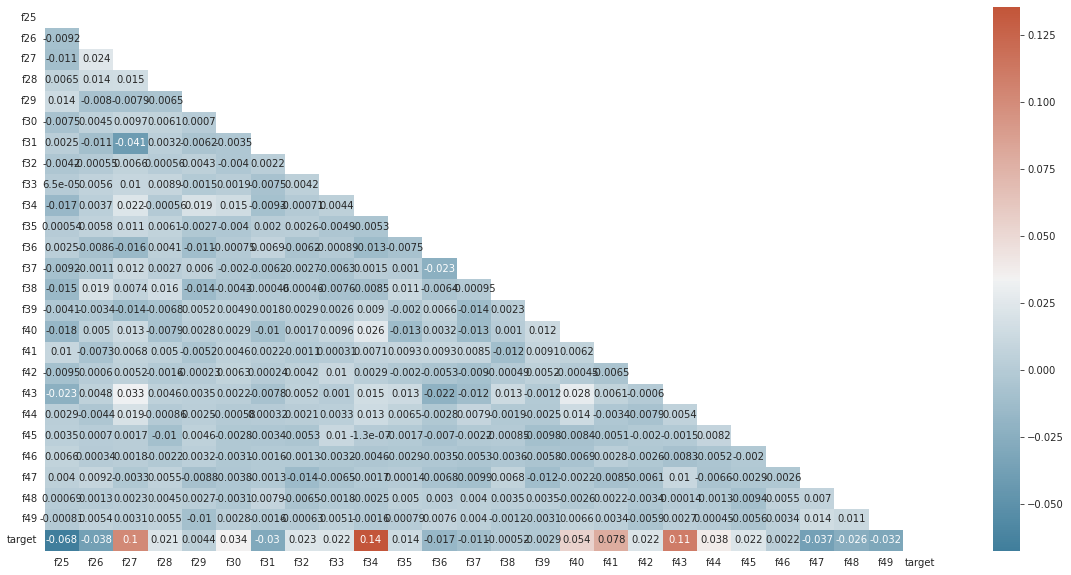

In [33]:
columns = train.columns[25:50].to_list()
columns.append('target')

corr = train[columns].corr()
f, ax = plt.subplots(figsize=(20,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, mask = mask, cmap=cmap)

**f50-f74** and **target** variable.

<AxesSubplot:>

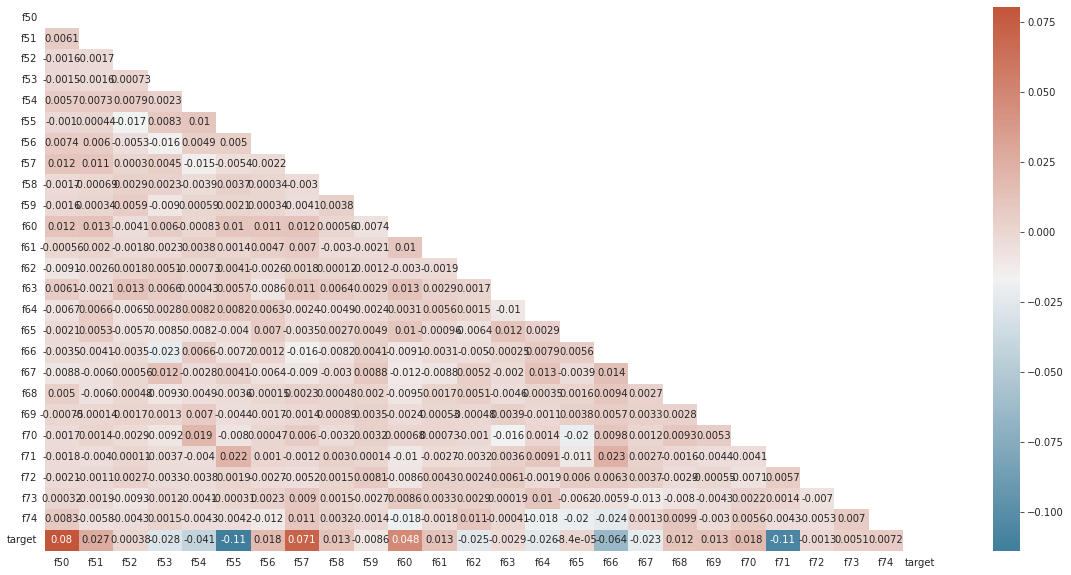

In [34]:
columns = train.columns[50:75].to_list()
columns.append('target')

corr = train[columns].corr()
f, ax = plt.subplots(figsize=(20,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, mask = mask, cmap=cmap)

**f75-f99** and **target** variable.

<AxesSubplot:>

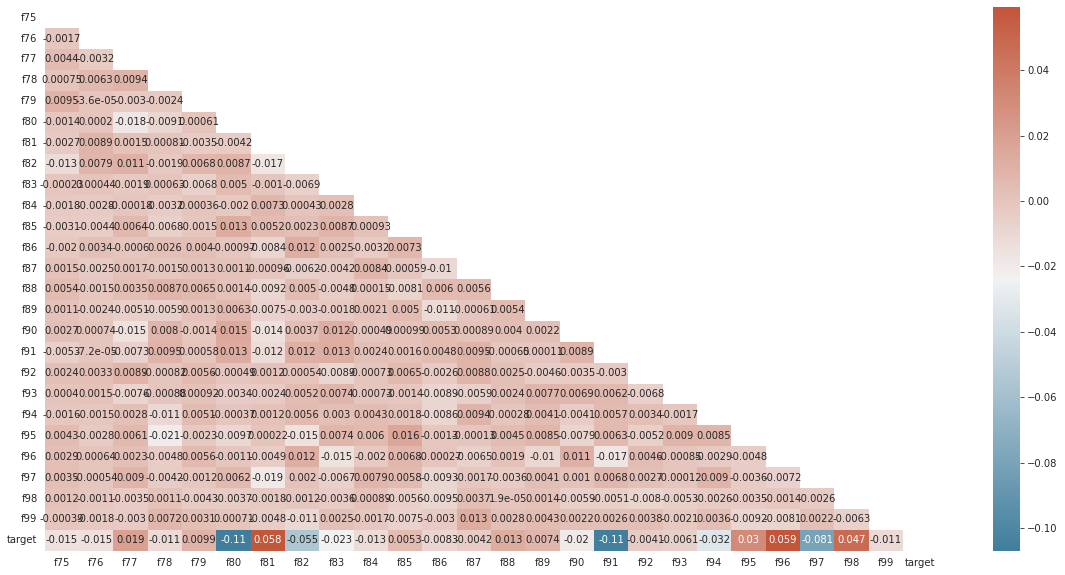

In [35]:
columns = train.columns[75:100].to_list()
columns.append('target')

corr = train[columns].corr()
f, ax = plt.subplots(figsize=(20,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, mask = mask, cmap=cmap)

It seems like there is common correlation coefficient(**0.11**) of some features with target variable.

# Feature Engineering

In [36]:
X = train.drop('target', axis=1).copy()
y = train['target']
X_test = test.copy()

del train
gc.collect
del test
gc.collect

<function gc.collect(generation=2)>

In [37]:
def feature_eng(df):
    df['sum'] = df.sum(axis=1)  
    df['min'] = df.min(axis=1)
    df['max'] = df.max(axis=1)
    df['mean'] = df.mean(axis=1)
    df['std'] = df.std(axis=1)
    df['skew'] = df.skew(axis=1)
    df['kurt'] = df.kurtosis(axis=1)
    return df

X = feature_eng(X)
X_test = feature_eng(X_test)

In [38]:
display(X.head())
display(X_test.head())

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,sum,min,max,mean,std,skew,kurt
0,0.106643,3.594370,132.804000,3.184280,0.081971,1.188590,3.732380,2.266270,2.099590,0.012330,1.607190,-0.318058,0.560137,2.806880,1.351140,2.535930,0.197527,0.676494,1.989790,-3.842450,0.037380,0.230322,3.330550,0.009397,0.144738,3.051310,1.303620,0.033225,-0.018284,2.748210,-0.009294,-0.036271,-0.049871,0.019484,3.898460,11.286300,1.138020,3.366880,4.944460,-0.105772,2.113450,3.452230,0.789430,1.113210,1.491570,2.440370,0.041824,3.355370,0.053691,1.701270,0.908831,0.094902,0.030219,0.597024,4.443410,1.586490,-0.068686,-0.108268,0.061044,0.046099,0.017113,-0.027551,0.019483,-0.048826,0.050748,3.729300,5.017440,4.186880,0.063342,0.121043,1.371750,4.017450,0.167613,0.039753,2.042360,-0.016614,0.107679,3.507250,0.013660,-0.097023,5.396070,0.244457,3.491840,0.113090,-0.015472,4.208790,4.106560,0.037227,-0.118814,0.067086,0.010739,1.098620,0.013331,-0.011715,0.052759,0.065400,4.211250,1.978770,0.085974,0.240496,265.660656,-3.842450,265.660656,7.700384,38.572241,6.207144,39.287176
1,0.125021,1.673360,76.533600,3.378250,0.099400,5.093660,1.275620,-0.471318,4.545940,0.037706,0.331749,0.325091,0.062040,2.262150,4.339430,-0.224999,0.233586,3.381280,1.902990,0.067874,-0.051268,0.006135,2.604440,0.103441,0.067638,4.753620,1.855520,-0.181834,0.008359,3.166340,0.011850,0.022292,0.069320,0.117109,0.315276,24.480700,1.672270,-0.409067,4.954750,0.092358,2.603180,1.954690,0.005896,3.289340,2.564530,0.817706,0.025997,4.617490,1.575540,0.066105,0.681634,0.025247,0.183500,0.110038,2.746120,0.835586,0.188196,4.960640,0.136087,-0.008493,-0.015264,-0.010841,0.064584,0.102548,0.093611,0.964089,0.630422,4.307340,0.091289,-0.036360,3.617670,3.103240,0.000657,0.051302,1.924620,0.123294,-0.022671,1.548120,-0.010397,0.058330,3.661310,-0.118386,2.357390,-0.009112,0.178701,4.097350,3.532890,0.005244,0.121381,0.109968,0.135838,3.460170,0.017054,0.124863,0.154064,0.606848,-0.267928,2.577860,-0.020877,0.024719,213.345638,-0.471318,213.345638,6.209375,30.192420,6.467320,42.889018
2,0.036330,1.497470,233.546000,2.194350,0.026914,3.126940,5.056870,3.849460,1.801870,0.056995,0.328684,2.968810,0.105244,2.069490,5.309860,1.354790,-0.262018,1.379080,1.480910,0.020542,-0.008806,0.109348,1.683650,0.038180,0.123716,1.112480,3.571660,0.120601,0.082069,2.233520,0.002270,0.045182,0.014405,0.011599,-0.502849,33.738200,1.417500,1.071350,3.222960,2.122030,3.082160,0.637555,-0.006822,-0.390943,17.345700,3.700430,-0.033600,1.578240,0.051978,-0.002004,2.690960,0.018367,-0.030468,0.111409,2.187470,-0.325000,-0.019944,3.455030,0.068105,-0.009812,-0.010627,0.027571,-0.007121,-0.048914,-0.002574,1.865090,2.404170,0.411741,0.057749,0.525174,2.168790,0.828297,0.089848,0.093744,4.949010,-0.010978,0.076671,0.266784,0.038691,0.382731,3.847600,-0.121482,3.740840,0.147098,-0.016566,0.614651,2.125840,0.078828,0.979808,0.026758,0.117310,4.883000,0.085222,0.032396,0.116092,-0.001688,-0.520069,2.141120,0.124464,0.148209,382.921747,-0.520069,382.921747,11.148011,57.178168,5.973127,36.106723
3,-0.014077,0.246000,779.967000,1.890640,0.006948,1.531120,2.698000,4.517330,4.503320,0.123494,1.002680,4.869600,0.058411,2.497850,1.238430,2.348360,0.175475,1.608890,2.028810,0.042086,0.005141,0.076506,1.651220,0.111813,0.121641,0.589120,4.236920,-0.032843,0.058168,0.712927,0.097465,0.072744,0.000324,0.063362,4.063820,25.382400,0.576572,2.026210,2.968430,1.085670,1.710880,1.371820,0.034631,0.722607,71.448500,3.034580,0.092245,3.453100,0.044829,0.027195,4.082850,0.046955,0.063695,0.029225,0.672022,0.185311,0.164284,3.804560,0.062306,-0.021406,0.009471,0.110884,0.026837,2.931160,0.068112,-0.4951

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,sum,min,max,mean,std,skew,kurt
0,0.003229,4.838660,585.529000,2.282910,0.713180,3.907830,0.480696,1.482270,4.891810,0.056351,4.200990,3.151800,0.000349,1.851160,2.638890,0.746668,-0.004756,1.610300,4.114820,-0.077756,0.129446,0.053324,0.416789,0.445009,0.150464,5.021300,2.221390,-0.072333,-0.215874,1.562360,0.074881,0.010050,0.018582,0.067466,5.578300,3.085560,3.842470,0.011125,2.359970,0.695092,-0.345747,4.388170,0.054919,2.803600,3.872340,3.974520,0.157887,0.704785,-0.001126,-0.004548,1.010820,0.094506,0.016935,0.100871,4.366950,1.832040,0.019682,1.964200,0.120581,0.080247,0.027516,0.048825,0.074626,0.041264,0.069319,4.248810,2.091950,0.695042,0.007464,-0.017882,1.883500,1.268030,0.023747,0.043071,3.174780,0.074356,0.125909,3.926430,0.046914,-0.042290,3.019250,0.089564,3.200700,0.009679,-0.099653,3.573060,4.797270,0.091985,0.773543,0.073380,0.112910,1.073550,0.122149,0.086330,0.036010,0.010619,0.290343,1.898200,0.131533,0.012047,710.199255,-0.345747,710.199255,20.682058,112.688927,5.729954,32.284667
1,0.008602,0.505536,-100.099000,3.012670,0.027199,1.194610,5.036620,2.517440,4.553890,0.063876,0.337257,4.439690,0.013188,3.379010,3.384700,1.167400,2.246550,1.750170,2.766240,-0.058501,0.012595,0.036144,0.769057,0.017496,0.050283,0.324697,4.948640,0.124789,0.347128,1.245120,0.035822,-0.013188,0.023194,0.006444,4.983330,23.706900,8.287290,4.796230,1.799280,-0.050040,1.973320,1.912010,0.035974,2.572370,6.321260,0.442628,0.148115,1.311350,0.106667,0.626128,2.309730,-0.044350,0.194283,0.131445,4.266670,0.715653,0.017117,2.839080,0.104712,-0.007952,0.067650,0.066438,0.034258,0.606144,0.019988,-0.456704,3.378770,1.900050,0.052316,-0.050397,2.612950,3.112540,0.022305,0.108325,4.617640,0.091440,0.039368,3.035190,1.023050,-0.020578,2.771560,3.309480,5.058400,-0.003993,0.067636,0.995391,2.471650,-0.015214,0.263423,-0.021910,-0.020214,2.622340,0.123307,0.033063,0.123059,0.005771,-0.392923,3.689640,0.047418,0.120015,55.183213,-100.099000,55.183213,0.635443,16.233898,-3.932820,30.169534
2,1.461000,2.437260,-112.964000,3.541230,0.752338,4.338310,1.648080,4.699910,1.950250,0.005303,2.071680,0.546499,0.141781,1.673170,4.306490,1.702330,-0.062869,1.619230,4.190530,0.055140,-0.016590,0.017805,3.064810,0.070370,0.098316,3.507540,1.069100,0.012750,0.009981,3.467810,0.035920,-0.009804,0.065728,-0.004725,5.281020,11.528800,0.171694,4.394570,2.520840,0.079365,5.451320,1.785820,0.029620,3.063830,5.275990,0.315972,0.148310,0.463193,-0.039962,0.150592,3.754600,0.024164,0.107455,0.048741,3.582400,0.966391,-0.058947,1.869830,0.029872,-0.044294,0.065172,-0.003328,-0.001950,0.095007,0.080267,3.337300,3.604890,4.694580,0.075650,-0.088276,1.772440,-0.142226,0.000918,0.021483,0.241844,0.067591,-0.026572,0.894909,0.111606,0.524423,1.450070,0.019355,1.271350,0.076042,0.446993,4.406990,2.446970,-0.041154,0.212414,0.141005,-0.011036,2.030180,-0.000426,0.084091,0.123605,0.499554,4.054650,3.330670,0.108843,0.064687,22.444438,-112.964000,22.444438,-0.443016,16.209131,-6.508596,44.740213
3,0.140556,3.085610,179.451000,0.573945,0.057342,2.216790,1.623480,0.526174,1.542540,-0.026160,1.609440,1.723560,-0.019564,1.552130,4.832640,1.501640,0.192669,4.614890,1.470690,-0.010031,0.072805,0.048035,3.230210,-0.031548,0.028697,3.752520,4.948470,-0.174542,-0.033491,2.478230,0.068129,0.090797,0.029877,0.146718,3.169830,-12.984600,3.135210,1.765010,3.253990,0.713238,3.729920,2.651530,0.080945,1.056490,1.452600,1.814190,0.077875,2.721310,0.004530,0.108844,2.834450,0.024642,-0.051423,0.060574,3.420200,1.283600,-0.083213,0.048820,-0.002502,0.051387,0.075775,-0.008900,0.141776,0.173123,0.012894,3.390590

Let's check the distribution of these new engineered features.

In [39]:
def plot_new_feature_distribution(df1, df2, label1, label2, features):
    i = 0
    sns.set_style('whitegrid')
    plt.figure()
    fig, ax = plt.subplots(2,4,figsize=(18,8))

    for feature in features:
        i += 1
        plt.subplot(2,4,i)
        sns.kdeplot(df1[feature], bw=0.5,label=label1)
        sns.kdeplot(df2[feature], bw=0.5,label=label2)
        plt.xlabel(feature, fontsize=11)
        locs, labels = plt.xticks()
        plt.tick_params(axis='x', which='major', labelsize=8)
        plt.tick_params(axis='y', which='major', labelsize=8)
    plt.show();

<Figure size 432x288 with 0 Axes>

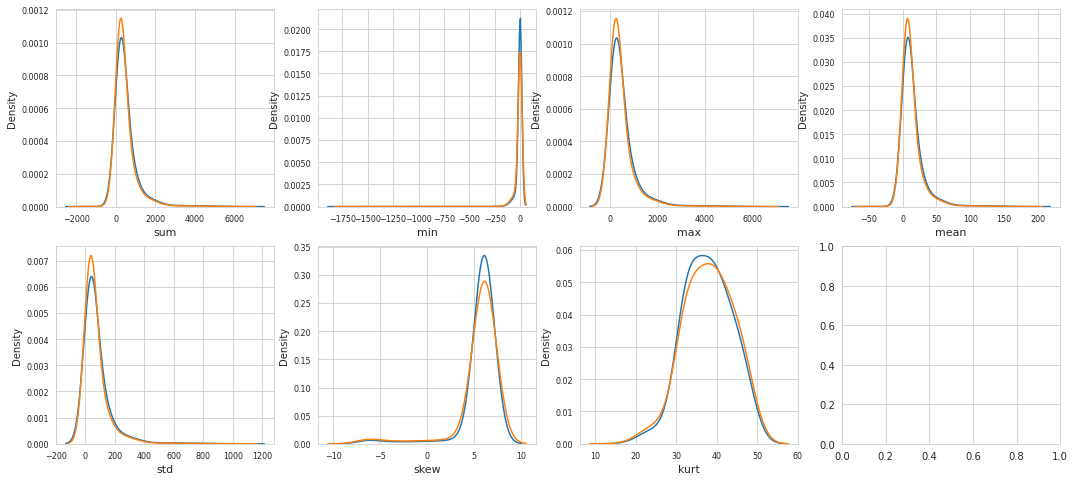

In [40]:
features = X.columns.values[100:107]
plot_new_feature_distribution(X, X_test, 'train', 'test', features)

# Model

In [41]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc

In [42]:
params = { 
          'objective': 'binary:logistic', 
          'gpu_id': 0, 
          'n_estimators': 10000, 
          'learning_rate': 0.01, 
          'gamma': 0.25, 
          'max_depth': 4, 
          'min_child_weight': 366, 
          'subsample': 0.64, 
          'colsample_bytree': 0.78, 
          'colsample_bylevel': 0.86, 
          'reg_lambda': 0, 
          'reg_alpha': 10
          }

In [43]:
%%time
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

preds = []
scores = []
feature_importance_df = pd.DataFrame()

for fold, (idx_train, idx_valid) in enumerate(kf.split(X, y)):
    X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
    X_valid, y_valid = X.iloc[idx_valid], y.iloc[idx_valid]
    
    model = XGBClassifier(**params,
                            booster= 'gbtree',
                            eval_metric = 'auc',
                            tree_method= 'gpu_hist',
                            predictor="gpu_predictor",
                            use_label_encoder=False)
    
    model.fit(X_train,y_train,
              eval_set=[(X_valid,y_valid)],
              early_stopping_rounds=100,
              verbose=False)
    
    pred_valid = model.predict_proba(X_valid)[:,1]
    fpr, tpr, _ = roc_curve(y_valid, pred_valid)
    score = auc(fpr, tpr)
    scores.append(score)
    
    fold_importance_df = pd.DataFrame()
    fold_importance_df["Feature"] = X.columns
    fold_importance_df["importance"] = model.feature_importances_
    fold_importance_df["fold"] = fold + 1
    feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0)
    
    print(f"Fold: {fold + 1} Score: {score}")
    print('||'*40)
    
    test_preds = model.predict_proba(X_test)[:,1]
    preds.append(test_preds)
    
print(f"Overall Validation Score: {np.mean(scores)}")

Fold: 1 Score: 0.7454026619069913
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Fold: 2 Score: 0.7457209195301471
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Fold: 3 Score: 0.7475697621979864
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Fold: 4 Score: 0.7468636617646655
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Fold: 5 Score: 0.749589957292027
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Overall Validation Score: 0.7470293925383634
CPU times: user 7min 35s, sys: 5.19 s, total: 7min 40s
Wall time: 7min 38s


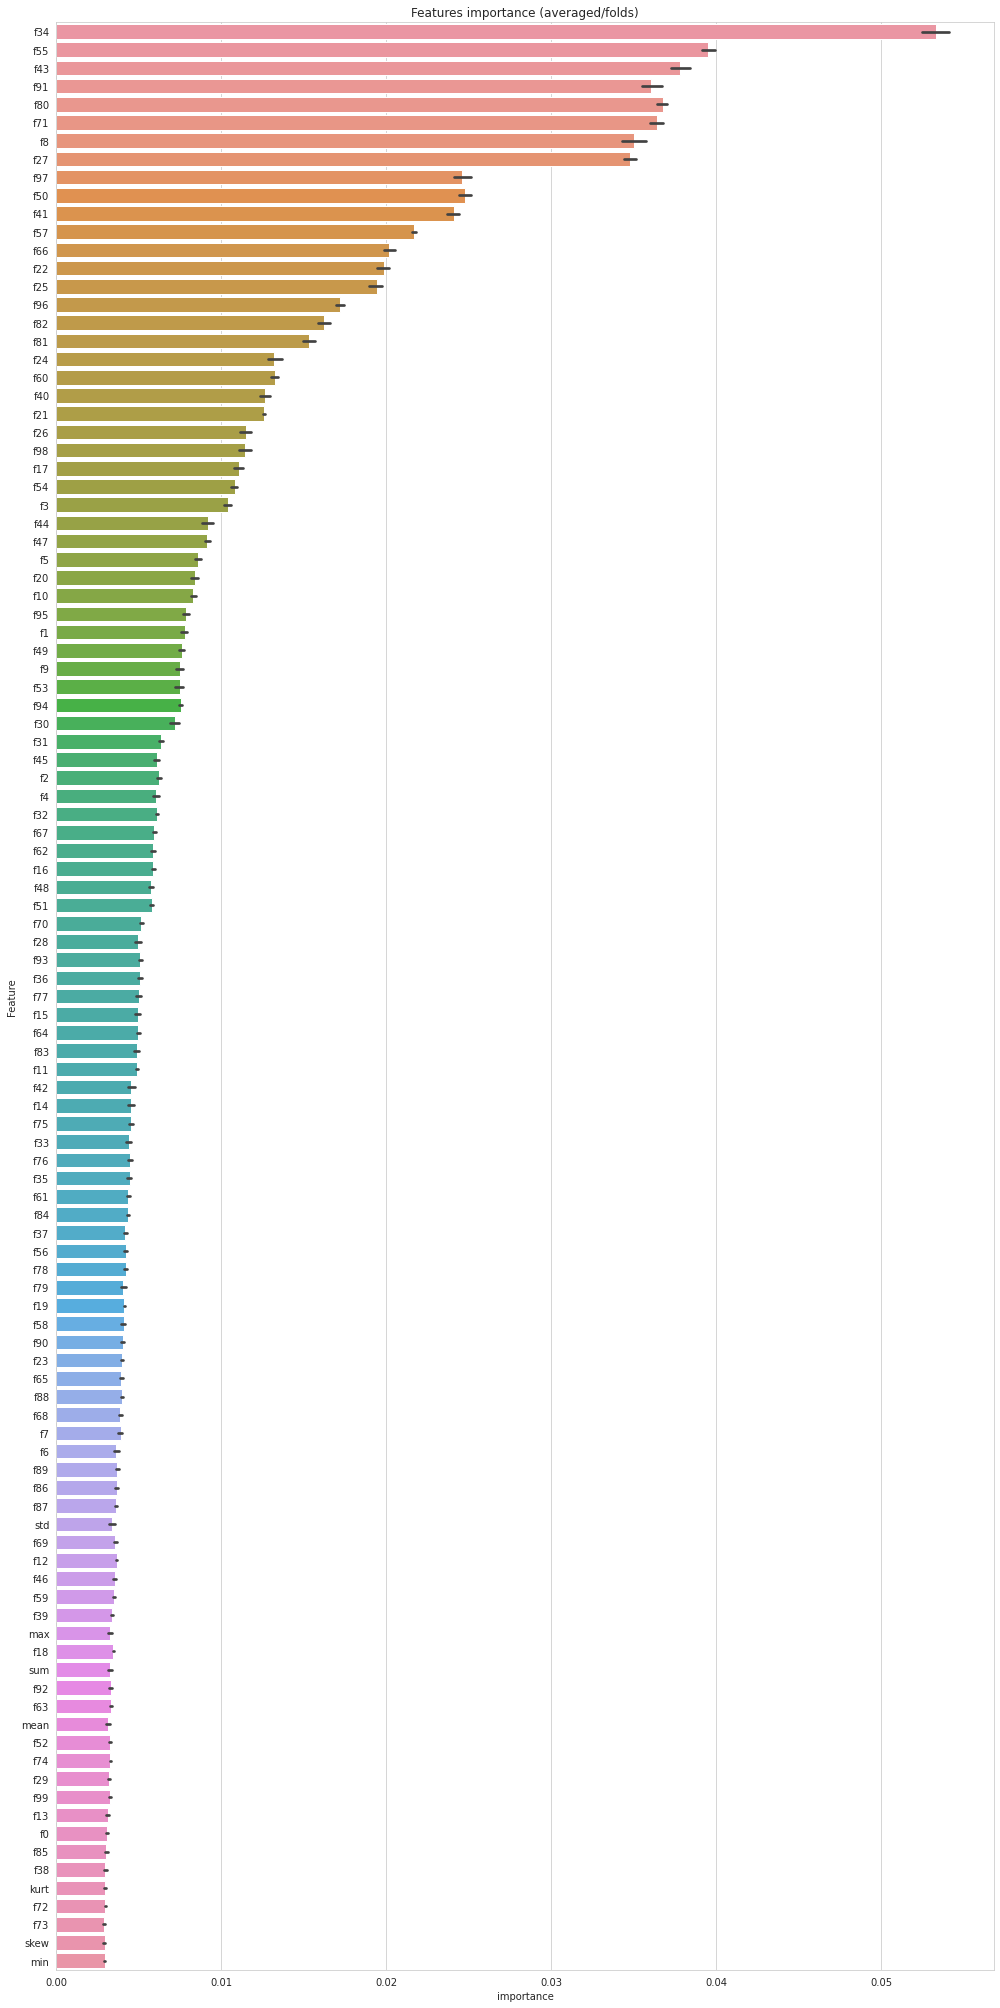

In [44]:
cols = (feature_importance_df[["Feature", "importance"]]
        .groupby("Feature")
        .mean()
        .sort_values(by="importance", ascending=False)[:107].index)
best_features = feature_importance_df.loc[feature_importance_df.Feature.isin(cols)]

plt.figure(figsize=(14,28))
sns.barplot(x="importance", y="Feature", data=best_features.sort_values(by="importance",ascending=False))
plt.title('Features importance (averaged/folds)')
plt.tight_layout()
plt.savefig('FI.png')

# Submission

In [45]:
predictions = np.mean(np.column_stack(preds),axis=1)

ss['target'] = predictions
ss.to_csv('./xgb.csv', index=False)
ss.head()

,id,target
0,600000,0.654272
1,600001,0.578737
2,600002,0.823731
3,600003,0.499812
4,600004,0.499747


# Reference
* https://www.kaggle.com/gpreda/santander-eda-and-prediction
* https://www.kaggle.com/subinium/tps-oct-simple-eda